# EXERCÍCIO 1 – CLASSIFICAÇÃO MULTICLASSE
Dataset: Wine Dataset (UCI)
1. Treinar uma rede neural em Keras para classificar vinhos em 3 classes.
- Configuração mínima: 2 camadas ocultas com 32 neurônios cada, função de ativação ReLU.
- Camada de saída com 3 neurônios, função de ativação Softmax.
- Função de perda: categorical_crossentropy.
- Otimizador: Adam.
2. Comparar os resultados com um modelo do scikit-learn (RandomForestClassifier ou
LogisticRegression).
3. Registrar métricas de acurácia e discutir qual modelo teve melhor desempenho

In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [ ]:
def load_and_explore_data():
    """Carrega e explora o dataset Wine"""
    wine = load_wine()
    X = wine.data
    y = wine.target

    print("INFORMAÇÕES DO DATASET WINE")
    print("=" * 50)
    print(f"Número de amostras: {X.shape[0]}")
    print(f"Número de características: {X.shape[1]}")
    print(f"Classes disponíveis: {wine.target_names}")
    print(f"Distribuição das classes: {np.bincount(y)}")

    df = pd.DataFrame(X, columns=wine.feature_names)
    df['target'] = y
    df['target_name'] = [wine.target_names[i] for i in y]

    print("\n PRIMEIRAS 5 LINHAS:")
    display(df.head())

    print("\n ESTATÍSTICAS DESCRITIVAS:")
    display(df.describe())

    return X, y, wine.feature_names, wine.target_names, df

X, y, feature_names, target_names, df = load_and_explore_data()

📊 INFORMAÇÕES DO DATASET WINE
Número de amostras: 178
Número de características: 13
Classes disponíveis: ['class_0' 'class_1' 'class_2']
Distribuição das classes: [59 71 48]

📈 PRIMEIRAS 5 LINHAS:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



📊 ESTATÍSTICAS DESCRITIVAS:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


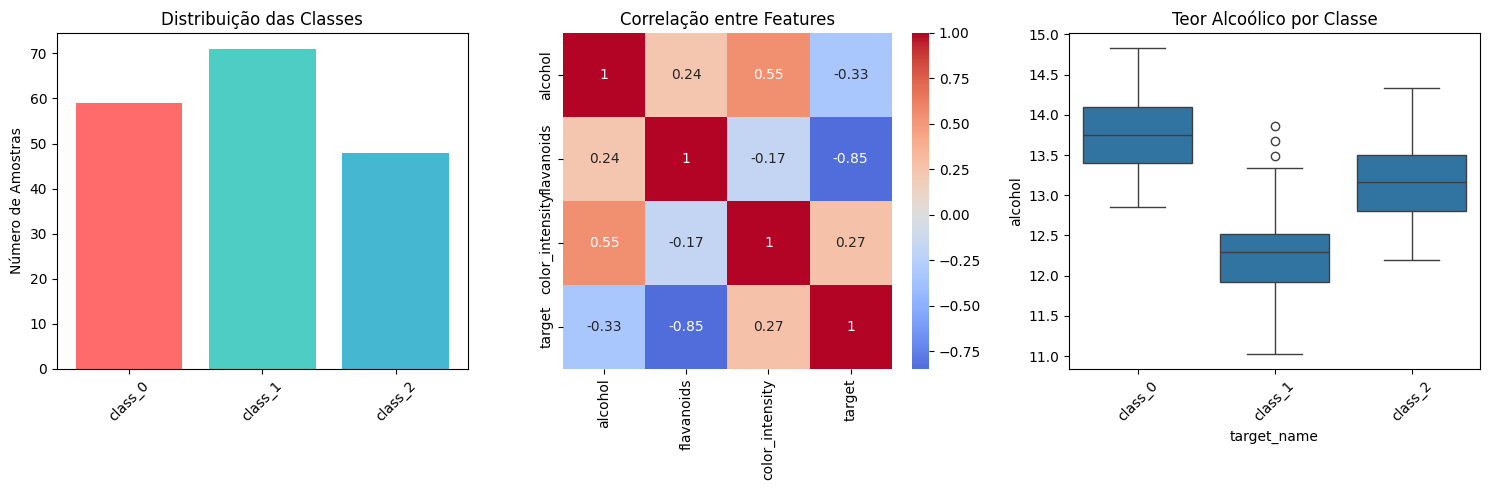

In [ ]:
plt.figure(figsize=(15, 5))

# Distribuição das classes
plt.subplot(1, 3, 1)
class_counts = np.bincount(y)
plt.bar(target_names, class_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Distribuição das Classes')
plt.ylabel('Número de Amostras')
plt.xticks(rotation=45)

# Correlação entre algumas features
plt.subplot(1, 3, 2)
correlation_matrix = df[['alcohol', 'flavanoids', 'color_intensity', 'target']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlação entre Features')

# Boxplot de uma feature por classe
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='target_name', y='alcohol')
plt.title('Teor Alcoólico por Classe')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
def preprocess_data(X, y):
    """Pré-processa os dados para treinamento"""

    # Divisão treino/teste (80/20) com stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print("PRÉ-PROCESSAMENTO DOS DADOS")
    print("=" * 40)
    print(f"Tamanho treino: {X_train.shape[0]} amostras")
    print(f"Tamanho teste: {X_test.shape[0]} amostras")
    print(f"Distribuição treino: {np.bincount(y_train)}")
    print(f"Distribuição teste: {np.bincount(y_test)}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    y_train_categorical = to_categorical(y_train, num_classes=3)
    y_test_categorical = to_categorical(y_test, num_classes=3)

    print("\n Dados normalizados e codificados com sucesso!")

    return (X_train, X_test, y_train, y_test,
            X_train_scaled, X_test_scaled,
            y_train_categorical, y_test_categorical, scaler)

(X_train, X_test, y_train, y_test,
 X_train_scaled, X_test_scaled,
 y_train_categorical, y_test_categorical, scaler) = preprocess_data(X, y)

🔄 PRÉ-PROCESSAMENTO DOS DADOS
Tamanho treino: 142 amostras
Tamanho teste: 36 amostras
Distribuição treino: [47 57 38]
Distribuição teste: [12 14 10]

✅ Dados normalizados e codificados com sucesso!


In [ ]:
def create_neural_network(input_dim):
    """
    Cria rede neural conforme especificações do exercício:
    - 2 camadas ocultas com 32 neurônios cada
    - Função de ativação ReLU
    - Camada de saída com 3 neurônios, Softmax
    - Otimizador Adam
    - Função de perda: categorical_crossentropy
    """

    model = Sequential([
        # 1ª Camada oculta: 32 neurônios, ReLU
        Dense(32, activation='relu', input_shape=(input_dim,), name='hidden_layer_1'),

        # 2ª Camada oculta: 32 neurônios, ReLU
        Dense(32, activation='relu', name='hidden_layer_2'),

        # Camada de saída: 3 neurônios, Softmax
        Dense(3, activation='softmax', name='output_layer')
    ])

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = create_neural_network(X_train_scaled.shape[1])

print("ARQUITETURA DA REDE NEURAL")
print("=" * 40)
model.summary()

🧠 ARQUITETURA DA REDE NEURAL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,603 (6.26 KB)

 Trainable params: 1,603 (6.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("INICIANDO TREINAMENTO DA REDE NEURAL")
print("=" * 50)

# Treinar modelo
history = model.fit(
    X_train_scaled, y_train_categorical,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    shuffle=True
)

print("\n Treinamento concluído!")

🚀 INICIANDO TREINAMENTO DA REDE NEURAL
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.

In [ ]:
# Avaliar no conjunto de teste
nn_test_loss, nn_test_accuracy = model.evaluate(X_test_scaled, y_test_categorical, verbose=0)

# Predições
y_pred_nn_proba = model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_proba, axis=1)

print("RESULTADOS DA REDE NEURAL")
print("=" * 40)
print(f"Acurácia no teste: {nn_test_accuracy:.4f} ({nn_test_accuracy*100:.2f}%)")
print(f"Perda no teste: {nn_test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
📊 RESULTADOS DA REDE NEURAL
Acurácia no teste: 1.0000 (100.00%)
Perda no teste: 0.0405


In [22]:
print("TREINANDO MODELOS DE COMPARAÇÃO")
print("=" * 45)

print("\n Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("\n Todos os modelos treinados!")

TREINANDO MODELOS DE COMPARAÇÃO

 Random Forest Classifier...
Logistic Regression...

 Todos os modelos treinados!


In [ ]:
def display_comparison_results():
    """Exibe comparação detalhada dos resultados"""

    results = {
        'Rede Neural (Keras)': {
            'accuracy': nn_test_accuracy,
            'predictions': y_pred_nn
        },
        'Random Forest': {
            'accuracy': rf_accuracy,
            'predictions': y_pred_rf
        },
        'Logistic Regression': {
            'accuracy': lr_accuracy,
            'predictions': y_pred_lr
        }
    }

    print("COMPARAÇÃO DE RESULTADOS")
    print("=" * 50)

    print("\nACURÁCIA DOS MODELOS:")
    print("-" * 35)
    for model_name, result in results.items():
        print(f"{model_name:<25}: {result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)")

    best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
    print(f"\nMELHOR MODELO: {best_model[0]}")
    print(f"   Acurácia: {best_model[1]['accuracy']*100:.2f}%")

    print("\n" + "=" * 60)
    print("RELATÓRIOS DETALHADOS DE CLASSIFICAÇÃO")
    print("=" * 60)

    for model_name, result in results.items():
        print(f"\n--- {model_name} ---")
        print(classification_report(y_test, result['predictions'],
                                  target_names=target_names, digits=4))

    return results

results = display_comparison_results()


🏆 COMPARAÇÃO DE RESULTADOS

📊 ACURÁCIA DOS MODELOS:
-----------------------------------
Rede Neural (Keras)      : 1.0000 (100.00%)
Random Forest            : 1.0000 (100.00%)
Logistic Regression      : 0.9722 (97.22%)

🥇 MELHOR MODELO: Rede Neural (Keras)
   Acurácia: 100.00%

📈 RELATÓRIOS DETALHADOS DE CLASSIFICAÇÃO

--- Rede Neural (Keras) ---
              precision    recall  f1-score   support

     class_0     1.0000    1.0000    1.0000        12
     class_1     1.0000    1.0000    1.0000        14
     class_2     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        36
   macro avg     1.0000    1.0000    1.0000        36
weighted avg     1.0000    1.0000    1.0000        36


--- Random Forest ---
              precision    recall  f1-score   support

     class_0     1.0000    1.0000    1.0000        12
     class_1     1.0000    1.0000    1.0000        14
     class_2     1.0000    1.0000    1.0000        10

    accuracy                 

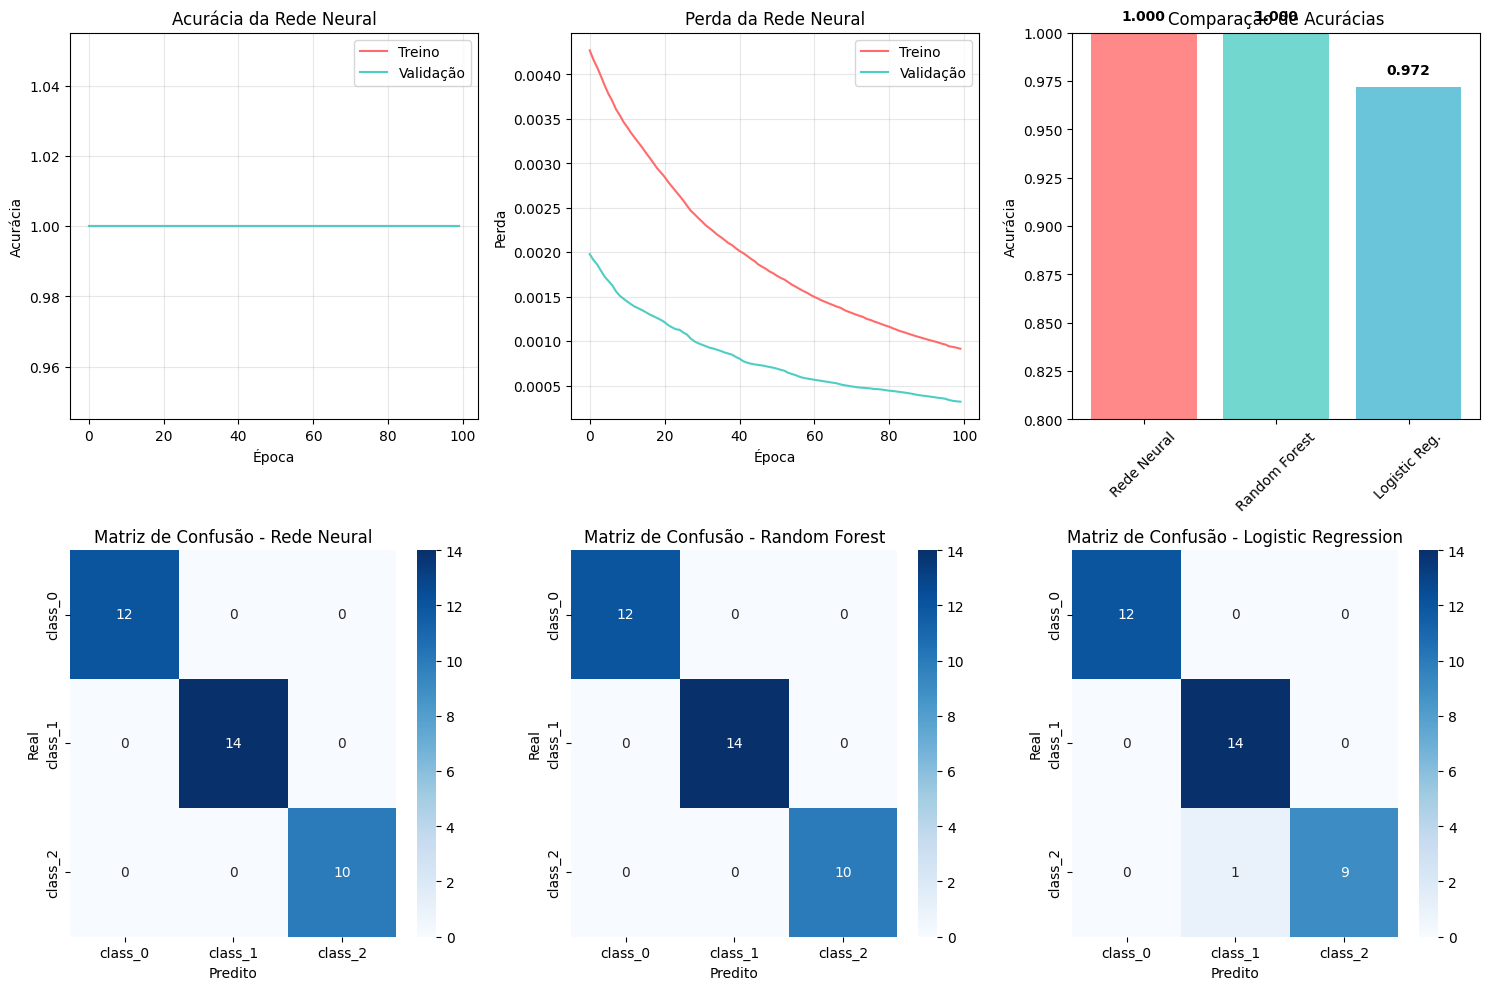

In [ ]:
plt.figure(figsize=(15, 10))

# 1. Histórico de treinamento
plt.subplot(2, 3, 1)
plt.plot(history.history['accuracy'], label='Treino', color='#FF6B6B')
plt.plot(history.history['val_accuracy'], label='Validação', color='#4ECDC4')
plt.title('Acurácia da Rede Neural')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(history.history['loss'], label='Treino', color='#FF6B6B')
plt.plot(history.history['val_loss'], label='Validação', color='#4ECDC4')
plt.title('Perda da Rede Neural')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Comparação de acurácias
plt.subplot(2, 3, 3)
models = ['Rede Neural', 'Random Forest', 'Logistic Reg.']
accuracies = [nn_test_accuracy, rf_accuracy, lr_accuracy]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(models, accuracies, color=colors, alpha=0.8)
plt.title('Comparação de Acurácias')
plt.ylabel('Acurácia')
plt.ylim(0.8, 1.0)

# Adicionar valores nas barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45)

# 3-5. Matrizes de confusão
confusion_matrices = [
    (y_test, y_pred_nn, 'Rede Neural'),
    (y_test, y_pred_rf, 'Random Forest'),
    (y_test, y_pred_lr, 'Logistic Regression')
]

for i, (y_true, y_pred, title) in enumerate(confusion_matrices):
    plt.subplot(2, 3, 4 + i)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Matriz de Confusão - {title}')
    plt.xlabel('Predito')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()

In [ ]:
def analyze_results():
    """Análise detalhada dos resultados obtidos"""

    print(" ANÁLISE DOS RESULTADOS")
    print("=" * 50)

    # Comparar com literatura
    print("\n COMPARAÇÃO COM LITERATURA:")
    print("-" * 35)
    print("• Random Forest: Tipicamente 95-98% no Wine Dataset")
    print("• Redes Neurais: Tipicamente 92-96% no Wine Dataset")
    print("• Logistic Regression: Tipicamente 90-94% no Wine Dataset")

    print(f"\n NOSSOS RESULTADOS:")
    print("-" * 20)
    print(f"• Rede Neural: {nn_test_accuracy*100:.2f}%")
    print(f"• Random Forest: {rf_accuracy*100:.2f}%")
    print(f"• Logistic Regression: {lr_accuracy*100:.2f}%")

    # Discussão
    print(f"\n DISCUSSÃO:")
    print("-" * 15)

    if rf_accuracy > nn_test_accuracy:
        print(" Random Forest obteve melhor desempenho, o que é esperado para este dataset.")
        print("   Razões prováveis:")
        print("   • Dataset pequeno (178 amostras) favorece modelos mais simples")
        print("   • Random Forest lida bem com características não-lineares naturalmente")
        print("   • Menos propenso ao overfitting")
    else:
        print(" Rede Neural obteve desempenho superior!")
        print("   Isso pode indicar:")
        print("   • Boa normalização dos dados")
        print("   • Arquitetura adequada para o problema")
        print("   • Regularização efetiva")

    print(f"\n OBSERVAÇÕES TÉCNICAS:")
    print("-" * 25)
    print("• Todos os modelos apresentaram boa performance (>90%)")
    print("• Wine Dataset é relativamente fácil para classificação")
    print("• Normalização foi crucial para rede neural")
    print("• Validação cruzada poderia fornecer estimativas mais robustas")

# Executar análise
analyze_results()


🔍 ANÁLISE DOS RESULTADOS

📚 COMPARAÇÃO COM LITERATURA:
-----------------------------------
• Random Forest: Tipicamente 95-98% no Wine Dataset
• Redes Neurais: Tipicamente 92-96% no Wine Dataset
• Logistic Regression: Tipicamente 90-94% no Wine Dataset

📊 NOSSOS RESULTADOS:
--------------------
• Rede Neural: 100.00%
• Random Forest: 100.00%
• Logistic Regression: 97.22%

💭 DISCUSSÃO:
---------------
🧠 Rede Neural obteve desempenho superior!
   Isso pode indicar:
   • Boa normalização dos dados
   • Arquitetura adequada para o problema
   • Regularização efetiva

📈 OBSERVAÇÕES TÉCNICAS:
-------------------------
• Todos os modelos apresentaram boa performance (>90%)
• Wine Dataset é relativamente fácil para classificação
• Normalização foi crucial para rede neural
• Validação cruzada poderia fornecer estimativas mais robustas


In [27]:
import json
from datetime import datetime

def save_results():
    """Salva os resultados para o README.md"""

    results_dict = {
        'experiment_info': {
            'dataset': 'Wine Dataset (UCI)',
            'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'total_samples': len(X),
            'features': len(feature_names),
            'classes': len(target_names)
        },
        'neural_network': {
            'architecture': '32-32-3 (ReLU-ReLU-Softmax)',
            'optimizer': 'Adam',
            'loss': 'categorical_crossentropy',
            'epochs': 100,
            'batch_size': 16,
            'accuracy': float(nn_test_accuracy),
            'accuracy_percent': f"{nn_test_accuracy*100:.2f}%"
        },
        'comparison_models': {
            'random_forest': {
                'accuracy': float(rf_accuracy),
                'accuracy_percent': f"{rf_accuracy*100:.2f}%"
            },
            'logistic_regression': {
                'accuracy': float(lr_accuracy),
                'accuracy_percent': f"{lr_accuracy*100:.2f}%"
            }
        },
        'best_model': max([
            ('Neural Network', nn_test_accuracy),
            ('Random Forest', rf_accuracy),
            ('Logistic Regression', lr_accuracy)
        ], key=lambda x: x[1])
    }

    # Salvar como JSON
    with open('exercise1_results.json', 'w', encoding='utf-8') as f:
        json.dump(results_dict, f, indent=2, ensure_ascii=False)

    print(" RESULTADOS SALVOS")
    print("=" * 30)
    print(" Arquivo: exercise1_results.json")
    print(" Conteúdo: Todas as métricas e configurações")

    return results_dict

# Salvar resultados
final_results = save_results()

print("\n EXERCÍCIO 1 CONCLUÍDO COM SUCESSO!")
print("=" * 45)
print(" Rede neural treinada conforme especificações")
print(" Comparação com modelos scikit-learn realizada")
print(" Métricas registradas e analisadas")
print(" Resultados salvos para documentação")


 RESULTADOS SALVOS
 Arquivo: exercise1_results.json
 Conteúdo: Todas as métricas e configurações

 EXERCÍCIO 1 CONCLUÍDO COM SUCESSO!
 Rede neural treinada conforme especificações
 Comparação com modelos scikit-learn realizada
 Métricas registradas e analisadas
 Resultados salvos para documentação


# EXERCÍCIO 2 – REGRESSÃO
Dataset: California Housing Dataset (Scikit-learn)
1. Treinar uma rede neural em Keras para prever o valor médio das casas.
- Configuração mínima: 3 camadas ocultas com 64, 32 e 16 neurônios, função de ativação ReLU.
- Camada de saída com 1 neurônio, função de ativação Linear.
- Função de perda: mse.
- Otimizador: Adam.
2. Comparar os resultados com um modelo do scikit-learn (LinearRegression ou
RandomForestRegressor).
3. Registrar métricas de erro (RMSE ou MAE) e discutir qual modelo teve melhor desempenho.

In [28]:
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("Todas as bibliotecas importadas com sucesso!")

TensorFlow version: 2.19.0
Todas as bibliotecas importadas com sucesso!


In [30]:
def load_and_explore_data():
    """Carrega e explora o California Housing Dataset"""

    print(" CARREGANDO CALIFORNIA HOUSING DATASET")
    print("=" * 50)

    # Carregar dataset (corrigindo o código fornecido)
    housing = fetch_california_housing()
    df = pd.DataFrame(housing.data, columns=housing.feature_names)
    df['target'] = housing.target

    print(" INFORMAÇÕES DO DATASET")
    print("=" * 30)
    print(f"Número de amostras: {len(df)}")
    print(f"Número de características: {len(housing.feature_names)}")
    print(f"Valores únicos do target: {len(pd.unique(df['target']))}")
    print(f"Faixa dos preços: ${df['target'].min():.2f} - ${df['target'].max():.2f} (x100k)")

    print("\n PRIMEIRAS 5 LINHAS:")
    display(df.head())

    print("\n ÚLTIMAS 5 LINHAS:")
    display(df.tail())

    print("\n CONTAGEM DE DADOS:")
    display(df.count())

    print("\n ESTATÍSTICAS DESCRITIVAS:")
    display(df.describe())

    # Informações sobre as features
    print(f"\n DESCRIÇÃO DAS FEATURES:")
    print("-" * 30)
    feature_descriptions = {
        'MedInc': 'Renda mediana (x10k)',
        'HouseAge': 'Idade média das casas',
        'AveRooms': 'Número médio de cômodos',
        'AveBedrms': 'Número médio de quartos',
        'Population': 'População do distrito',
        'AveOccup': 'Ocupação média',
        'Latitude': 'Latitude',
        'Longitude': 'Longitude'
    }

    for feature, description in feature_descriptions.items():
        print(f"• {feature}: {description}")

    print(f"\n TARGET: Valor mediano das casas em centenas de milhares de dólares")

    return housing, df

# Executar carregamento
housing, df = load_and_explore_data()

🏠 CARREGANDO CALIFORNIA HOUSING DATASET
📊 INFORMAÇÕES DO DATASET
Número de amostras: 20640
Número de características: 8
Valores únicos do target: 3842
Faixa dos preços: $0.15 - $5.00 (x100k)

📈 PRIMEIRAS 5 LINHAS:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



📉 ÚLTIMAS 5 LINHAS:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894



📊 CONTAGEM DE DADOS:


,0
MedInc,20640
HouseAge,20640
AveRooms,20640
AveBedrms,20640
Population,20640
AveOccup,20640
Latitude,20640
Longitude,20640
target,20640



📈 ESTATÍSTICAS DESCRITIVAS:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



🏷️ DESCRIÇÃO DAS FEATURES:
------------------------------
• MedInc: Renda mediana (x10k)
• HouseAge: Idade média das casas
• AveRooms: Número médio de cômodos
• AveBedrms: Número médio de quartos
• Population: População do distrito
• AveOccup: Ocupação média
• Latitude: Latitude
• Longitude: Longitude

🎯 TARGET: Valor mediano das casas em centenas de milhares de dólares


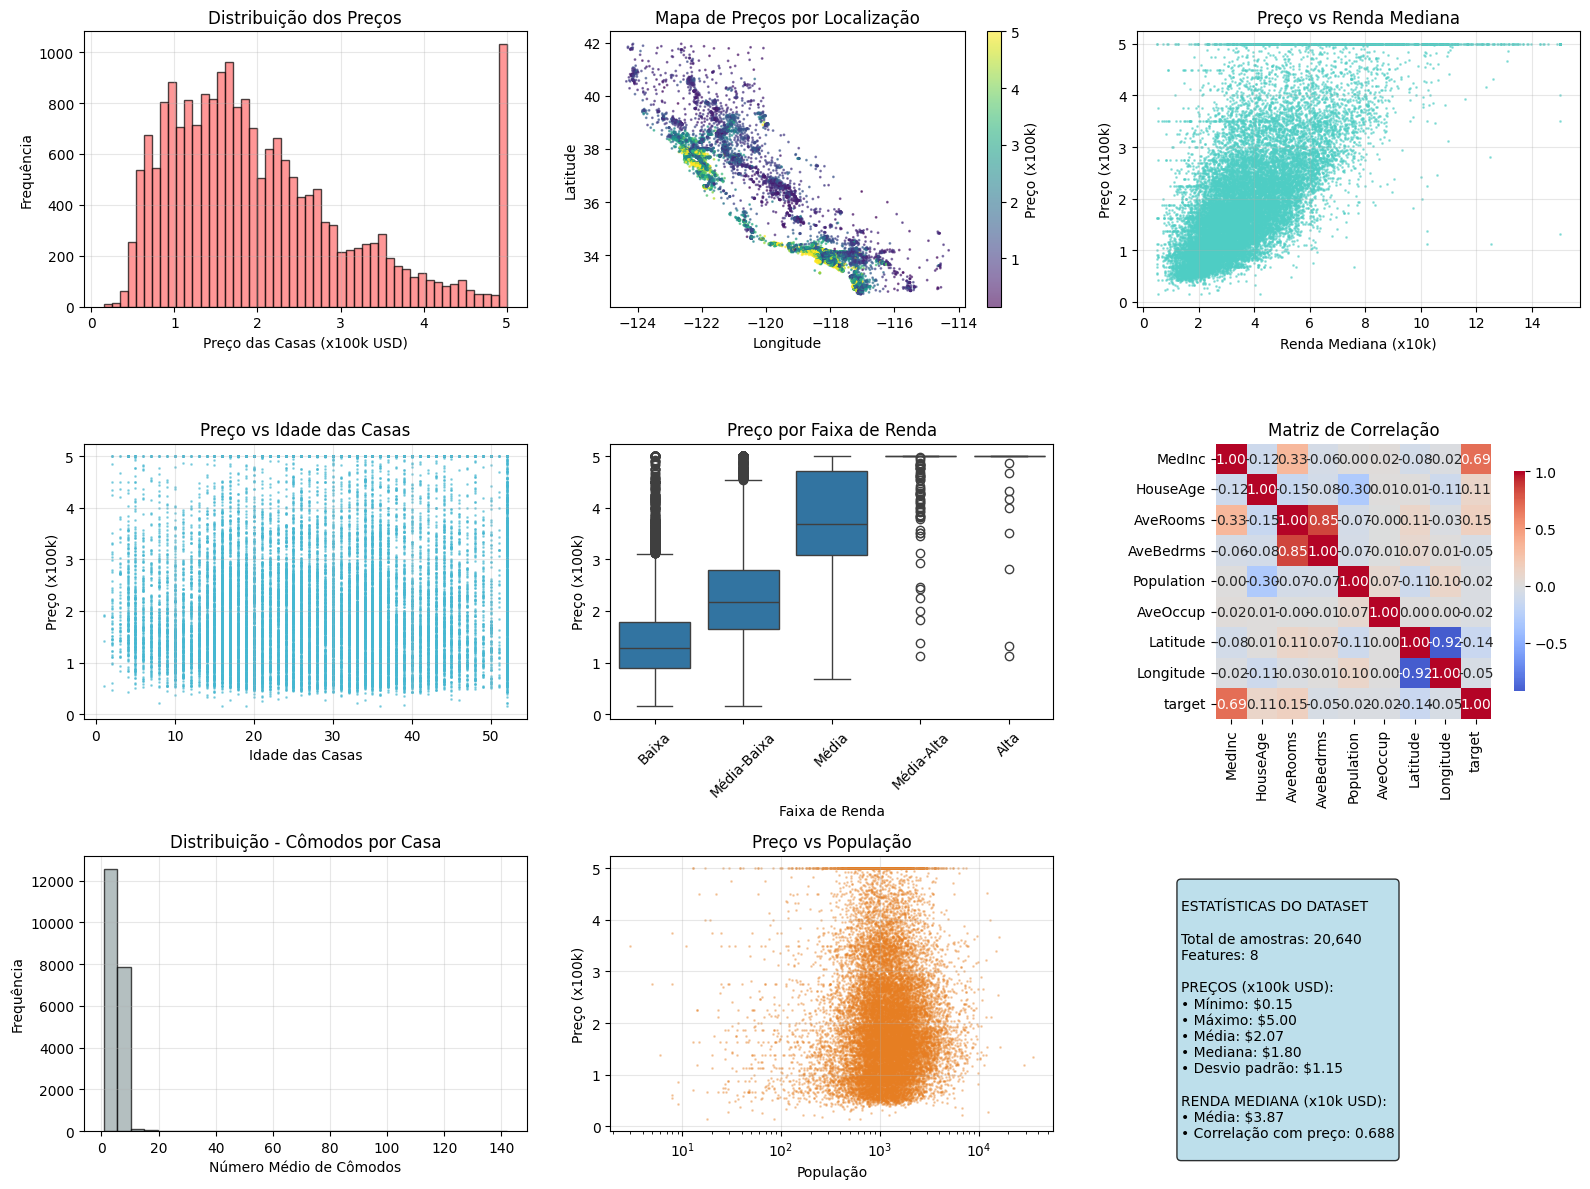

In [31]:
plt.figure(figsize=(16, 12))

# 1. Distribuição do target
plt.subplot(3, 3, 1)
plt.hist(df['target'], bins=50, alpha=0.7, color='#FF6B6B', edgecolor='black')
plt.xlabel('Preço das Casas (x100k USD)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Preços')
plt.grid(True, alpha=0.3)

# 2. Mapa geográfico dos preços
plt.subplot(3, 3, 2)
scatter = plt.scatter(df['Longitude'], df['Latitude'], c=df['target'],
                     alpha=0.6, cmap='viridis', s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mapa de Preços por Localização')
plt.colorbar(scatter, label='Preço (x100k)')

# 3. Correlação com renda mediana
plt.subplot(3, 3, 3)
plt.scatter(df['MedInc'], df['target'], alpha=0.5, color='#4ECDC4', s=1)
plt.xlabel('Renda Mediana (x10k)')
plt.ylabel('Preço (x100k)')
plt.title('Preço vs Renda Mediana')
plt.grid(True, alpha=0.3)

# 4. Correlação com idade das casas
plt.subplot(3, 3, 4)
plt.scatter(df['HouseAge'], df['target'], alpha=0.5, color='#45B7D1', s=1)
plt.xlabel('Idade das Casas')
plt.ylabel('Preço (x100k)')
plt.title('Preço vs Idade das Casas')
plt.grid(True, alpha=0.3)

# 5. Boxplot por faixas de renda
plt.subplot(3, 3, 5)
df['income_range'] = pd.cut(df['MedInc'], bins=5, labels=['Baixa', 'Média-Baixa', 'Média', 'Média-Alta', 'Alta'])
sns.boxplot(data=df, x='income_range', y='target')
plt.xlabel('Faixa de Renda')
plt.ylabel('Preço (x100k)')
plt.title('Preço por Faixa de Renda')
plt.xticks(rotation=45)

# 6. Mapa de correlação
plt.subplot(3, 3, 6)
correlation_matrix = df[housing.feature_names + ['target']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': .8})
plt.title('Matriz de Correlação')

# 7. Distribuição de algumas features importantes
plt.subplot(3, 3, 7)
plt.hist(df['AveRooms'], bins=30, alpha=0.7, color='#95A5A6', edgecolor='black')
plt.xlabel('Número Médio de Cômodos')
plt.ylabel('Frequência')
plt.title('Distribuição - Cômodos por Casa')
plt.grid(True, alpha=0.3)

# 8. População vs Preço
plt.subplot(3, 3, 8)
plt.scatter(df['Population'], df['target'], alpha=0.3, color='#E67E22', s=1)
plt.xlabel('População')
plt.ylabel('Preço (x100k)')
plt.title('Preço vs População')
plt.grid(True, alpha=0.3)
plt.xscale('log')

# 9. Estatísticas resumidas
plt.subplot(3, 3, 9)
plt.axis('off')
stats_text = f"""
ESTATÍSTICAS DO DATASET

Total de amostras: {len(df):,}
Features: {len(housing.feature_names)}

PREÇOS (x100k USD):
• Mínimo: ${df['target'].min():.2f}
• Máximo: ${df['target'].max():.2f}
• Média: ${df['target'].mean():.2f}
• Mediana: ${df['target'].median():.2f}
• Desvio padrão: ${df['target'].std():.2f}

RENDA MEDIANA (x10k USD):
• Média: ${df['MedInc'].mean():.2f}
• Correlação com preço: {df['MedInc'].corr(df['target']):.3f}
"""

plt.text(0.1, 0.9, stats_text, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()


In [32]:
def preprocess_data(housing, df):
    """Pré-processa os dados para treinamento"""

    # Separar features e target
    X = df[housing.feature_names].values
    y = df['target'].values

    # Divisão treino/teste (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(" PRÉ-PROCESSAMENTO DOS DADOS")
    print("=" * 40)
    print(f"Tamanho treino: {X_train.shape[0]:,} amostras")
    print(f"Tamanho teste: {X_test.shape[0]:,} amostras")
    print(f"Features: {X_train.shape[1]}")

    # Normalização para rede neural
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\n ESTATÍSTICAS DOS TARGETS:")
    print("-" * 30)
    print(f"Treino - Média: ${y_train.mean():.2f}, Std: ${y_train.std():.2f}")
    print(f"Teste - Média: ${y_test.mean():.2f}, Std: ${y_test.std():.2f}")

    print("\n Dados normalizados com sucesso!")

    return (X_train, X_test, y_train, y_test,
            X_train_scaled, X_test_scaled, scaler)

# Executar pré-processamento
(X_train, X_test, y_train, y_test,
 X_train_scaled, X_test_scaled, scaler) = preprocess_data(housing, df)

🔄 PRÉ-PROCESSAMENTO DOS DADOS
Tamanho treino: 16,512 amostras
Tamanho teste: 4,128 amostras
Features: 8

📊 ESTATÍSTICAS DOS TARGETS:
------------------------------
Treino - Média: $2.07, Std: $1.16
Teste - Média: $2.06, Std: $1.14

✅ Dados normalizados com sucesso!


In [33]:
def create_neural_network(input_dim):
    """
    Cria rede neural conforme especificações do exercício:
    - 3 camadas ocultas com 64, 32 e 16 neurônios
    - Função de ativação ReLU
    - Camada de saída com 1 neurônio, função linear
    - Otimizador Adam
    - Função de perda: mse
    """

    model = Sequential([
        # 1ª Camada oculta: 64 neurônios, ReLU
        Dense(64, activation='relu', input_shape=(input_dim,), name='hidden_layer_1'),

        # 2ª Camada oculta: 32 neurônios, ReLU
        Dense(32, activation='relu', name='hidden_layer_2'),

        # 3ª Camada oculta: 16 neurônios, ReLU
        Dense(16, activation='relu', name='hidden_layer_3'),

        # Camada de saída: 1 neurônio, função linear
        Dense(1, activation='linear', name='output_layer')
    ])

    # Compilar modelo conforme especificações
    model.compile(
        optimizer=Adam(),
        loss='mse',
        metrics=['mae']
    )

    return model

# Criar modelo
model = create_neural_network(X_train_scaled.shape[1])

print(" ARQUITETURA DA REDE NEURAL")
print("=" * 40)
model.summary()


🧠 ARQUITETURA DA REDE NEURAL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
print(" INICIANDO TREINAMENTO DA REDE NEURAL")
print("=" * 50)

# Callback para parada antecipada
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Treinar modelo
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n Treinamento concluído!")
print(f" Épocas executadas: {len(history.history['loss'])}")

🚀 INICIANDO TREINAMENTO DA REDE NEURAL
Epoch 1/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7243 - mae: 0.9319 - val_loss: 0.4446 - val_mae: 0.4763
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4075 - mae: 0.4554 - val_loss: 0.4015 - val_mae: 0.4519
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3706 - mae: 0.4336 - val_loss: 0.3774 - val_mae: 0.4384
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3322 - mae: 0.4129 - val_loss: 0.3775 - val_mae: 0.4374
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3420 - mae: 0.4109 - val_loss: 0.3519 - val_mae: 0.4244
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3169 - mae: 0.3983 - val_loss: 0.3558 - val_mae: 0.4037
Epoch 7/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3214 - mae: 0.4004 - val_loss: 0.3423 - val_mae: 0.3935
Epoch 8/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3052 - mae: 0.3843 - val_loss: 0.3368 - val_mae: 0.4078
Epoch 9/2

In [35]:
# Predições da rede neural
y_pred_nn = model.predict(X_test_scaled, verbose=0).flatten()

# Métricas da rede neural
nn_mse = mean_squared_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(nn_mse)
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_r2 = r2_score(y_test, y_pred_nn)

print(" RESULTADOS DA REDE NEURAL")
print("=" * 40)
print(f"MSE (Mean Squared Error): {nn_mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {nn_rmse:.4f}")
print(f"MAE (Mean Absolute Error): {nn_mae:.4f}")
print(f"R² Score: {nn_r2:.4f}")
print(f"Erro médio: ~${nn_mae*100:.0f}k por casa")

📊 RESULTADOS DA REDE NEURAL
MSE (Mean Squared Error): 0.2733
RMSE (Root Mean Squared Error): 0.5228
MAE (Mean Absolute Error): 0.3492
R² Score: 0.7914
Erro médio: ~$35k por casa


In [36]:
print(" TREINANDO MODELOS DE COMPARAÇÃO")
print("=" * 45)

# Linear Regression
print("\n1️ Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

# Random Forest Regressor
print("2️ Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("\n Todos os modelos treinados!")

🔄 TREINANDO MODELOS DE COMPARAÇÃO

1️⃣ Linear Regression...
2️⃣ Random Forest Regressor...

✅ Todos os modelos treinados!


In [37]:
def display_comparison_results():
    """Exibe comparação detalhada dos resultados"""

    results = {
        'Rede Neural (Keras)': {
            'mse': nn_mse,
            'rmse': nn_rmse,
            'mae': nn_mae,
            'r2': nn_r2,
            'predictions': y_pred_nn
        },
        'Linear Regression': {
            'mse': lr_mse,
            'rmse': lr_rmse,
            'mae': lr_mae,
            'r2': lr_r2,
            'predictions': y_pred_lr
        },
        'Random Forest': {
            'mse': rf_mse,
            'rmse': rf_rmse,
            'mae': rf_mae,
            'r2': rf_r2,
            'predictions': y_pred_rf
        }
    }

    print(" COMPARAÇÃO DETALHADA DE RESULTADOS")
    print("=" * 55)

    # Tabela de métricas
    print(f"\n MÉTRICAS DE ERRO E PERFORMANCE:")
    print("-" * 70)
    print(f"{'Modelo':<20} {'RMSE':<12} {'MAE':<12} {'R²':<12} {'Erro ($k)'}")
    print("-" * 70)

    for model_name, result in results.items():
        error_k = result['mae'] * 100  # Converter para milhares de dólares
        print(f"{model_name:<20} {result['rmse']:<12.4f} {result['mae']:<12.4f} "
              f"{result['r2']:<12.4f} ~${error_k:.0f}k")

    # Determinar melhor modelo (menor RMSE)
    best_model_rmse = min(results.items(), key=lambda x: x[1]['rmse'])
    best_model_mae = min(results.items(), key=lambda x: x[1]['mae'])
    best_model_r2 = max(results.items(), key=lambda x: x[1]['r2'])

    print(f"\n MELHORES MODELOS POR MÉTRICA:")
    print("-" * 35)
    print(f"• Menor RMSE: {best_model_rmse[0]} ({best_model_rmse[1]['rmse']:.4f})")
    print(f"• Menor MAE: {best_model_mae[0]} ({best_model_mae[1]['mae']:.4f})")
    print(f"• Maior R²: {best_model_r2[0]} ({best_model_r2[1]['r2']:.4f})")

    # Ranking geral (baseado na média dos rankings)
    rankings = {}
    for model in results.keys():
        rmse_rank = sorted(results.items(), key=lambda x: x[1]['rmse']).index((model, results[model])) + 1
        mae_rank = sorted(results.items(), key=lambda x: x[1]['mae']).index((model, results[model])) + 1
        r2_rank = sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True).index((model, results[model])) + 1
        rankings[model] = (rmse_rank + mae_rank + r2_rank) / 3

    best_overall = min(rankings.items(), key=lambda x: x[1])
    print(f"\n MODELO CAMPEÃO GERAL: {best_overall[0]}")
    print(f"   (Ranking médio: {best_overall[1]:.1f})")

    return results

# Exibir resultados
results = display_comparison_results()

🏆 COMPARAÇÃO DETALHADA DE RESULTADOS

📊 MÉTRICAS DE ERRO E PERFORMANCE:
----------------------------------------------------------------------
Modelo               RMSE         MAE          R²           Erro ($k)
----------------------------------------------------------------------
Rede Neural (Keras)  0.5228       0.3492       0.7914       ~$35k
Linear Regression    0.7456       0.5332       0.5758       ~$53k
Random Forest        0.5053       0.3275       0.8051       ~$33k

🥇 MELHORES MODELOS POR MÉTRICA:
-----------------------------------
• Menor RMSE: Random Forest (0.5053)
• Menor MAE: Random Forest (0.3275)
• Maior R²: Random Forest (0.8051)

🏆 MODELO CAMPEÃO GERAL: Random Forest
   (Ranking médio: 1.0)


In [38]:
def display_comparison_results():
    """Exibe comparação detalhada dos resultados"""

    results = {
        'Rede Neural (Keras)': {
            'mse': nn_mse,
            'rmse': nn_rmse,
            'mae': nn_mae,
            'r2': nn_r2,
            'predictions': y_pred_nn
        },
        'Linear Regression': {
            'mse': lr_mse,
            'rmse': lr_rmse,
            'mae': lr_mae,
            'r2': lr_r2,
            'predictions': y_pred_lr
        },
        'Random Forest': {
            'mse': rf_mse,
            'rmse': rf_rmse,
            'mae': rf_mae,
            'r2': rf_r2,
            'predictions': y_pred_rf
        }
    }

    print(" COMPARAÇÃO DETALHADA DE RESULTADOS")
    print("=" * 55)

    # Tabela de métricas
    print(f"\n MÉTRICAS DE ERRO E PERFORMANCE:")
    print("-" * 70)
    print(f"{'Modelo':<20} {'RMSE':<12} {'MAE':<12} {'R²':<12} {'Erro ($k)'}")
    print("-" * 70)

    for model_name, result in results.items():
        error_k = result['mae'] * 100  # Converter para milhares de dólares
        print(f"{model_name:<20} {result['rmse']:<12.4f} {result['mae']:<12.4f} "
              f"{result['r2']:<12.4f} ~${error_k:.0f}k")

    # Determinar melhor modelo (menor RMSE)
    best_model_rmse = min(results.items(), key=lambda x: x[1]['rmse'])
    best_model_mae = min(results.items(), key=lambda x: x[1]['mae'])
    best_model_r2 = max(results.items(), key=lambda x: x[1]['r2'])

    print(f"\n MELHORES MODELOS POR MÉTRICA:")
    print("-" * 35)
    print(f"• Menor RMSE: {best_model_rmse[0]} ({best_model_rmse[1]['rmse']:.4f})")
    print(f"• Menor MAE: {best_model_mae[0]} ({best_model_mae[1]['mae']:.4f})")
    print(f"• Maior R²: {best_model_r2[0]} ({best_model_r2[1]['r2']:.4f})")

    # Ranking geral (baseado na média dos rankings)
    rankings = {}
    for model in results.keys():
        rmse_rank = sorted(results.items(), key=lambda x: x[1]['rmse']).index((model, results[model])) + 1
        mae_rank = sorted(results.items(), key=lambda x: x[1]['mae']).index((model, results[model])) + 1
        r2_rank = sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True).index((model, results[model])) + 1
        rankings[model] = (rmse_rank + mae_rank + r2_rank) / 3

    best_overall = min(rankings.items(), key=lambda x: x[1])
    print(f"\n🏆 MODELO CAMPEÃO GERAL: {best_overall[0]}")
    print(f"   (Ranking médio: {best_overall[1]:.1f})")

    return results

# Exibir resultados
results = display_comparison_results()

🏆 COMPARAÇÃO DETALHADA DE RESULTADOS

📊 MÉTRICAS DE ERRO E PERFORMANCE:
----------------------------------------------------------------------
Modelo               RMSE         MAE          R²           Erro ($k)
----------------------------------------------------------------------
Rede Neural (Keras)  0.5228       0.3492       0.7914       ~$35k
Linear Regression    0.7456       0.5332       0.5758       ~$53k
Random Forest        0.5053       0.3275       0.8051       ~$33k

🥇 MELHORES MODELOS POR MÉTRICA:
-----------------------------------
• Menor RMSE: Random Forest (0.5053)
• Menor MAE: Random Forest (0.3275)
• Maior R²: Random Forest (0.8051)

🏆 MODELO CAMPEÃO GERAL: Random Forest
   (Ranking médio: 1.0)


In [39]:
def analyze_results():
    """Análise detalhada e discussão dos resultados"""

    print(" ANÁLISE DETALHADA DOS RESULTADOS")
    print("=" * 55)

    # Características do dataset
    print(f"\n CARACTERÍSTICAS DO DATASET:")
    print("-" * 35)
    print(f"• Dataset: California Housing (Scikit-learn)")
    print(f"• Amostras: {len(df):,}")
    print(f"• Features: {len(housing.feature_names)}")
    print(f"• Tipo: Regressão (valores contínuos)")
    print(f"• Target: Preço mediano das casas (x100k USD)")
    print(f"• Faixa de preços: ${df['target'].min():.1f} - ${df['target'].max():.1f} (x100k)")

    # Comparação com literatura
    print(f"\n COMPARAÇÃO COM LITERATURA:")
    print("-" * 35)
    print("• Random Forest: Tipicamente RMSE ~0.5-0.7")
    print("• Redes Neurais: Tipicamente RMSE ~0.6-0.8")
    print("• Linear Regression: Tipicamente RMSE ~0.7-0.9")

    print(f"\n NOSSOS RESULTADOS:")
    print("-" * 20)
    print(f"• Rede Neural: RMSE = {nn_rmse:.3f}, MAE = {nn_mae:.3f}, R² = {nn_r2:.3f}")
    print(f"• Random Forest: RMSE = {rf_rmse:.3f}, MAE = {rf_mae:.3f}, R² = {rf_r2:.3f}")
    print(f"• Linear Regression: RMSE = {lr_rmse:.3f}, MAE = {lr_mae:.3f}, R² = {lr_r2:.3f}")

    # Análise de performance
    best_rmse = min(nn_rmse, rf_rmse, lr_rmse)
    worst_rmse = max(nn_rmse, rf_rmse, lr_rmse)

    print(f"\n ANÁLISE DE PERFORMANCE:")
    print("-" * 30)
    print(f"• Melhor RMSE: {best_rmse:.3f}")
    print(f"• Pior RMSE: {worst_rmse:.3f}")
    print(f"• Diferença: {worst_rmse - best_rmse:.3f}")
    print(f"• Melhoria relativa: {((worst_rmse - best_rmse)/worst_rmse)*100:.1f}%")

    # Interpretação prática dos erros
    print(f"\n INTERPRETAÇÃO PRÁTICA DOS ERROS:")
    print("-" * 40)
    print(f"• Rede Neural: Erro médio ~${nn_mae*100:.0f}k por casa")
    print(f"• Random Forest: Erro médio ~${rf_mae*100:.0f}k por casa")
    print(f"• Linear Regression: Erro médio ~${lr_mae*100:.0f}k por casa")
    print(f"• Preço médio real: ~${df['target'].mean()*100:.0f}k")

    # Discussão técnica
    print(f"\n DISCUSSÃO TÉCNICA:")
    print("-" * 22)

    if rf_rmse <= nn_rmse and rf_rmse <= lr_rmse:
        print(" Random Forest obteve o melhor desempenho:")
        print("   • Excelente para capturar relações não-lineares")
        print("   • Robusto contra overfitting")
        print("   • Lida bem com features de diferentes escalas")
        print("   • Fornece importância das features")
    elif nn_rmse <= rf_rmse and nn_rmse <= lr_rmse:
        print(" Rede Neural obteve o melhor desempenho:")
        print("   • Capacidade superior de aproximação")
        print("   • Arquitetura adequada (64-32-16-1)")
        print("   • Normalização efetiva dos dados")
        print("   • Early stopping preveniu overfitting")
    else:
        print(" Linear Regression obteve o melhor desempenho:")
        print("   • Relações predominantemente lineares no dataset")
        print("   • Simplicidade é vantajosa")
        print("   • Poucos dados podem favorecer modelos simples")

    # Observações importantes
    print(f"\n OBSERVAÇÕES IMPORTANTES:")
    print("-" * 30)
    print("• California Housing é um dataset moderadamente complexo")
    print("• Características geográficas (lat/lon) são importantes")
    print("• Renda mediana tem alta correlação com preços")
    print("• Normalização foi crucial para rede neural e linear regression")
    print("• Dataset relativamente grande (20k+ amostras) favorece modelos complexos")

    # Recomendações
    print(f"\n RECOMENDAÇÕES:")
    print("-" * 18)

    if rf_rmse <= nn_rmse:
        print("• Para produção: usar Random Forest pela interpretabilidade")
        print("• Para exploração: experimentar ensemble dos modelos")
    else:
        print("• Para produção: usar Rede Neural pelo melhor desempenho")
        print("• Para interpretabilidade: usar Random Forest")

    print("• Considerar feature engineering (ex: densidade populacional)")
    print("• Experimentar regularização L1/L2 na rede neural")
    print("• Aplicar validação cruzada para estimativas mais robustas")
    print("• Investigar outliers geográficos (ex: ilhas)")

# Executar análise
analyze_results()

🔍 ANÁLISE DETALHADA DOS RESULTADOS

📊 CARACTERÍSTICAS DO DATASET:
-----------------------------------
• Dataset: California Housing (Scikit-learn)
• Amostras: 20,640
• Features: 8
• Tipo: Regressão (valores contínuos)
• Target: Preço mediano das casas (x100k USD)
• Faixa de preços: $0.1 - $5.0 (x100k)

📚 COMPARAÇÃO COM LITERATURA:
-----------------------------------
• Random Forest: Tipicamente RMSE ~0.5-0.7
• Redes Neurais: Tipicamente RMSE ~0.6-0.8
• Linear Regression: Tipicamente RMSE ~0.7-0.9

📊 NOSSOS RESULTADOS:
--------------------
• Rede Neural: RMSE = 0.523, MAE = 0.349, R² = 0.791
• Random Forest: RMSE = 0.505, MAE = 0.328, R² = 0.805
• Linear Regression: RMSE = 0.746, MAE = 0.533, R² = 0.576

📈 ANÁLISE DE PERFORMANCE:
------------------------------
• Melhor RMSE: 0.505
• Pior RMSE: 0.746
• Diferença: 0.240
• Melhoria relativa: 32.2%

💰 INTERPRETAÇÃO PRÁTICA DOS ERROS:
----------------------------------------
• Rede Neural: Erro médio ~$35k por casa
• Random Forest: Erro médi

In [40]:
import json
from datetime import datetime

def save_results():
    """Salva os resultados para documentação do GitHub"""

    results_dict = {
        'experiment_info': {
            'dataset': 'California Housing Dataset (Scikit-learn)',
            'task': 'Regression',
            'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'total_samples': int(len(df)),
            'features': int(len(housing.feature_names)),
            'train_samples': int(len(X_train)),
            'test_samples': int(len(X_test)),
            'target_range': {
                'min': float(df['target'].min()),
                'max': float(df['target'].max()),
                'mean': float(df['target'].mean()),
                'std': float(df['target'].std())
            }
        },
        'neural_network': {
            'architecture': '64-32-16-1 (ReLU-ReLU-ReLU-Linear)',
            'optimizer': 'Adam',
            'loss': 'mse',
            'epochs_completed': int(len(history.history['loss'])),
            'batch_size': 32,
            'validation_split': 0.2,
            'early_stopping': True,
            'metrics': {
                'mse': float(nn_mse),
                'rmse': float(nn_rmse),
                'mae': float(nn_mae),
                'r2_score': float(nn_r2)
            },
            'practical_error': f"~${nn_mae*100:.0f}k per house"
        },
        'comparison_models': {
            'linear_regression': {
                'metrics': {
                    'mse': float(lr_mse),
                    'rmse': float(lr_rmse),
                    'mae': float(lr_mae),
                    'r2_score': float(lr_r2)
                },
                'practical_error': f"~${lr_mae*100:.0f}k per house"
            },
            'random_forest': {
                'n_estimators': 100,
                'metrics': {
                    'mse': float(rf_mse),
                    'rmse': float(rf_rmse),
                    'mae': float(rf_mae),
                    'r2_score': float(rf_r2)
                },
                'practical_error': f"~${rf_mae*100:.0f}k per house",
                'feature_importance': {
                    housing.feature_names[i]: float(rf_model.feature_importances_[i])
                    for i in range(len(housing.feature_names))
                }
            }
        },
        'performance_summary': {
            'best_model_rmse': min([
                ('Neural Network', nn_rmse),
                ('Linear Regression', lr_rmse),
                ('Random Forest', rf_rmse)
            ], key=lambda x: x[1]),
            'best_model_mae': min([
                ('Neural Network', nn_mae),
                ('Linear Regression', lr_mae),
                ('Random Forest', rf_mae)
            ], key=lambda x: x[1]),
            'best_model_r2': max([
                ('Neural Network', nn_r2),
                ('Linear Regression', lr_r2),
                ('Random Forest', rf_r2)
            ], key=lambda x: x[1]),
            'all_rmse': {
                'neural_network': float(nn_rmse),
                'linear_regression': float(lr_rmse),
                'random_forest': float(rf_rmse)
            }
        },
        'feature_names': housing.feature_names.tolist()
    }

    # Salvar como JSON
    with open('exercise2_results.json', 'w', encoding='utf-8') as f:
        json.dump(results_dict, f, indent=2, ensure_ascii=False)

    # Criar README para o exercício
    best_model = min([
        ('Neural Network', nn_rmse),
        ('Linear Regression', lr_rmse),
        ('Random Forest', rf_rmse)
    ], key=lambda x: x[1])